In [142]:
# Support Vector Machine (SVM) classification on Social Network Ads
# Goal: compare different SVM kernels and choose the best one
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn import metrics


In [143]:
df = pd.read_csv('Social_Network_Ads.csv')
print(df.head())
print(df.info())


    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   User ID          400 non-null    int64
 1   Gender           400 non-null    str  
 2   Age              400 non-null    int64
 3   EstimatedSalary  400 non-null    int64
 4   Purchased        400 non-null    int64
dtypes: int64(4), str(1)
memory usage: 17.7 KB
None


In [144]:
df.shape


(400, 5)

In [145]:
X = df.iloc[:, [2, 3]].values
y = df.iloc[:, 4].values


In [146]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)
print("training set X_train shape:", X_train.shape)
print("training set y_train shape:", y_train.shape)


training set X_train shape: (300, 2)
training set y_train shape: (300,)


In [147]:
print("training set X_train shape:", X_train.shape)
print("training set Y_train shape:", Y_train.shape)

training set X_train shape: (300, 2)
training set Y_train shape: (300,)


In [148]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


In [149]:
# Linear kernel
classifier = SVC(kernel='linear', random_state=0)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
print("Linear kernel accuracy:", metrics.accuracy_score(y_test, y_pred))


Linear kernel accuracy: 0.9


In [150]:
y_pred


array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1])

In [151]:
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("Precision:", metrics.precision_score(y_test, y_pred, zero_division=0))
print("Recall:", metrics.recall_score(y_test, y_pred, zero_division=0))
print("F1 Score:", metrics.f1_score(y_test, y_pred, zero_division=0))
print("Confusion Matrix:\n", metrics.confusion_matrix(y_test, y_pred))


Accuracy: 0.9
Precision: 0.9230769230769231
Recall: 0.75
F1 Score: 0.8275862068965517
Confusion Matrix:
 [[66  2]
 [ 8 24]]


In [152]:
# RBF kernel
classifier = SVC(kernel='rbf', random_state=0)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
print("RBF kernel accuracy:", metrics.accuracy_score(y_test, y_pred))


RBF kernel accuracy: 0.93


In [153]:
# Compare all kernels
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
for kernel in kernels:
    classifier = SVC(kernel=kernel, random_state=0)
    classifier.fit(X_train, y_train)
    y_pred = classifier.predict(X_test)
    acc = metrics.accuracy_score(y_test, y_pred)
    print(f"Kernel: {kernel} | Accuracy: {acc:.4f}")

# Tuned RBF example
classifier = SVC(kernel='rbf', C=7, gamma=15, random_state=0)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
print("Best tuned accuracy:", metrics.accuracy_score(y_test, y_pred))


Kernel: linear | Accuracy: 0.9000
Kernel: rbf | Accuracy: 0.9300
Kernel: poly | Accuracy: 0.8600
Kernel: sigmoid | Accuracy: 0.7400
Best tuned accuracy: 0.89


In [154]:
# Polynomial kernel
classifier = SVC(kernel='poly', degree=3, random_state=0)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
print("Polynomial kernel accuracy:", metrics.accuracy_score(y_test, y_pred))


Polynomial kernel accuracy: 0.86


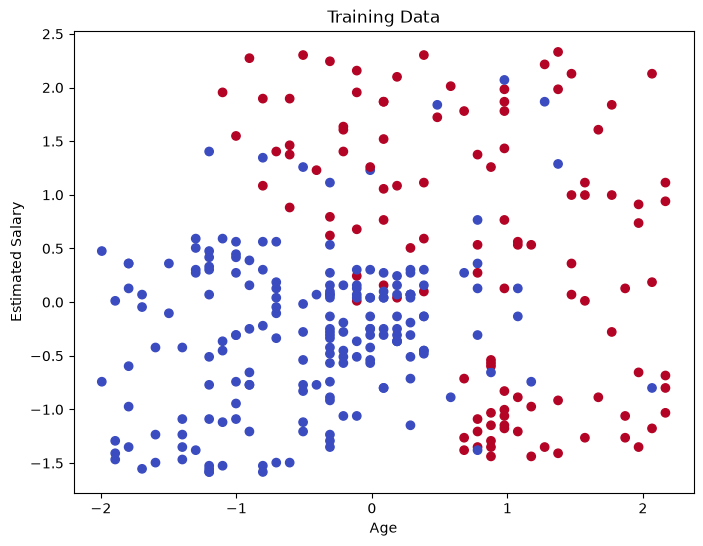

In [155]:
# Plot training data
plt.figure(figsize=(8, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm')
plt.title('Training Data')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.show()


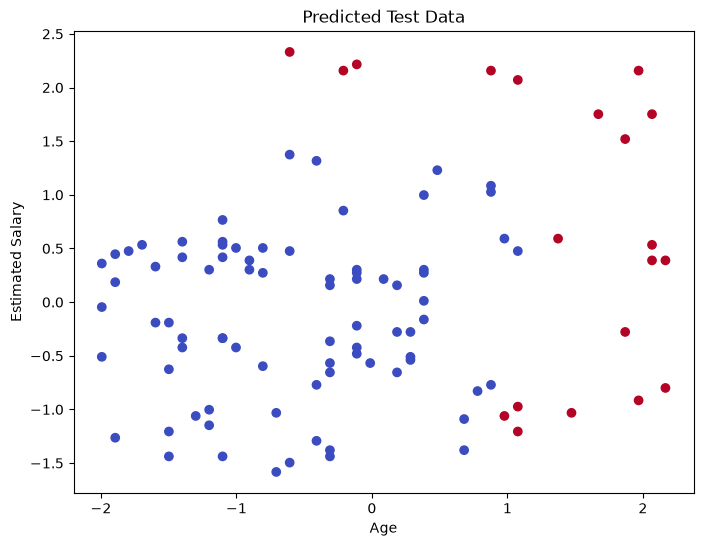

In [156]:
# Plot predictions on test data
plt.figure(figsize=(8, 6))
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred, cmap='coolwarm')
plt.title('Predicted Test Data')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.show()


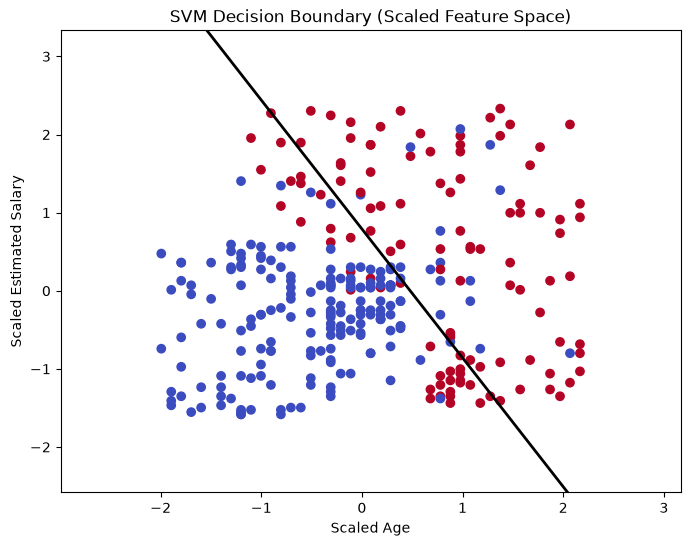

In [157]:
# Decision boundary for linear SVM
# Important: the model is trained on scaled features, so the boundary must be plotted
# in the same scaled feature space as the training data.
classifier = SVC(kernel='linear', random_state=0)
classifier.fit(X_train, y_train)

w = classifier.coef_[0]
intercept = classifier.intercept_[0]

x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx = np.linspace(x_min, x_max, 100)
A = -w[0] / w[1]
B = -intercept / w[1]
yy = A * xx + B

plt.figure(figsize=(8, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm')
plt.plot(xx, yy, 'k-', linewidth=2)
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.title('SVM Decision Boundary (Scaled Feature Space)')
plt.xlabel('Scaled Age')
plt.ylabel('Scaled Estimated Salary')
plt.show()
